# Notebook 03 — Analyse und Visualisierung

**SBB Tracker · ZHAW Scientific Programming FS2026**
Joël Hasler & Patrick Ferreira

In diesem Notebook beantworten wir vier konkrete Forschungsfragen
mit klassischen Statistik-Tests (alle mit p-Value-Reporting) und
visualisieren die Ergebnisse:

| # | Forschungsfrage | Methode |
|---|---|---|
| 1 | Sind Züge am Wochenende pünktlicher als an Werktagen? | Welch's t-Test |
| 2 | Gibt es Unterschiede in der Verspätung zwischen Linien-Typen? | Einweg-ANOVA |
| 3 | Korreliert Niederschlag/Temperatur mit Verspätung? | Pearson + Spearman |
| 4 | Welche Faktoren erklären Verspätung gemeinsam? | Multiple OLS-Regression |

Die OLS-Regression als vierter Test geht über das Kurslevel hinaus
(statsmodels), bringt aber wertvolle multivariate Erkenntnisse.


## Bibliotheken und Einstellungen


In [1]:
# Bibliotheken und Einstellungen
import os
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(color_codes=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Aktuelles Verzeichnis:", os.getcwd())
print("Projekt-Root:", PROJECT_ROOT)


Aktuelles Verzeichnis: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project\notebooks
Projekt-Root: C:\Users\hasle\Documents\Scientific Programming\SBB Tracker\project


In [2]:
# Zusaetzlich fuer Stats
import sys
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sys.path.insert(0, str(PROJECT_ROOT / "app"))
import utils


## Daten laden

Wir lesen den in Notebook 02 vorbereiteten, angereicherten Datensatz.


In [3]:
df = pd.read_parquet(DATA_PROCESSED / "delays_prepared.parquet")
print(f"Geladen: {len(df):,} Zeilen, {df.shape[1]} Spalten")
print(f"Zeitraum: {df['betriebstag'].min()}  bis  {df['betriebstag'].max()}")
print(f"Stationen: {df['haltestellen_name'].nunique():,}")
print(f"Linien:    {df['linien_text'].nunique():,}")


Geladen: 2,739,804 Zeilen, 31 Spalten
Zeitraum: 2026-03-31 00:00:00  bis  2026-05-19 00:00:00
Stationen: 658
Linien:    133


## Deskriptive Statistik der Ankunftsverspätung

Bevor wir Tests rechnen, ein erster Blick auf die Verteilung der
Verspätungen (in Sekunden).


In [4]:
s = df["delay_arr_sec"]
desc = pd.DataFrame({
    "Metrik": ["N", "Mittelwert", "Median", "StdAbw",
               "Min", "P05", "P25", "P75", "P95", "P99", "Max",
               "Anteil > 3 Min (klassisch verspaetet)"],
    "Wert": [
        f"{len(s):,}",
        f"{s.mean():.1f} s",
        f"{s.median():.1f} s",
        f"{s.std():.1f} s",
        f"{s.min():.0f} s",
        f"{s.quantile(.05):.0f} s",
        f"{s.quantile(.25):.0f} s",
        f"{s.quantile(.75):.0f} s",
        f"{s.quantile(.95):.0f} s",
        f"{s.quantile(.99):.0f} s",
        f"{s.max():.0f} s",
        f"{100*(s > 180).mean():.2f}%",
    ]
})
desc


,Metrik,Wert
0,N,"2,739,804"
1,Mittelwert,45.4 s
2,Median,28.0 s
3,StdAbw,202.1 s
4,Min,-173092 s
5,P05,-52 s
6,P25,-5 s
7,P75,69 s
8,P95,181 s
9,P99,409 s


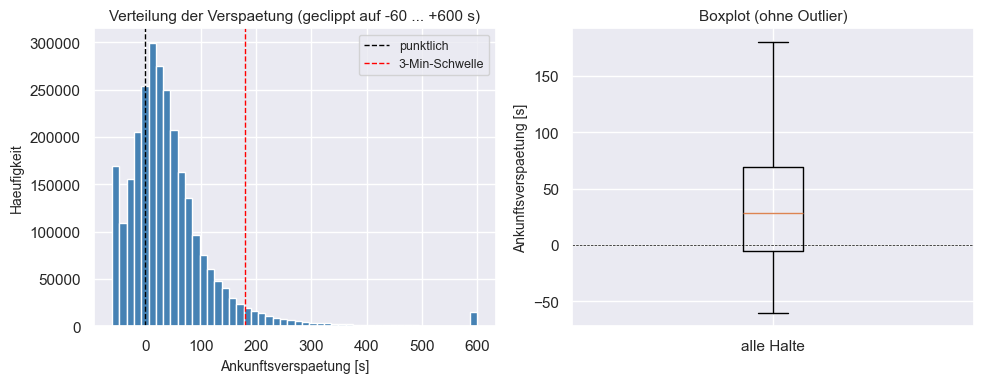

In [5]:
# Histogramm + Boxplot der Verspaetungen
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogramm geclippt fuer Lesbarkeit
s_clip = s.clip(-60, 600)
axes[0].hist(s_clip, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="punktlich")
axes[0].axvline(180, color="red", linewidth=1, linestyle="--", label="3-Min-Schwelle")
axes[0].set_xlabel("Ankunftsverspaetung [s]", fontsize=10)
axes[0].set_ylabel("Haeufigkeit", fontsize=10)
axes[0].set_title("Verteilung der Verspaetung (geclippt auf -60 ... +600 s)", fontsize=11)
axes[0].legend(fontsize=9)

axes[1].boxplot(s_clip, vert=True, showfliers=False)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Ankunftsverspaetung [s]", fontsize=10)
axes[1].set_title("Boxplot (ohne Outlier)", fontsize=11)
axes[1].set_xticklabels(["alle Halte"])

plt.tight_layout()
plt.show()


## Test 1: Werktag vs. Wochenende — Welch's t-Test

**Hypothesen:**
- H₀: Die mittlere Verspätung an Werktagen ist gleich der am Wochenende.
- H₁: Die mittlere Verspätung unterscheidet sich.

Wir nutzen **Welch's t-Test** (`equal_var=False`), weil Werktag und
Wochenende sehr unterschiedliche Zugfrequenz und damit andere
Varianzen haben.


In [6]:
weekday_delays = df.loc[~df["is_weekend"], "delay_arr_sec"]
weekend_delays = df.loc[df["is_weekend"], "delay_arr_sec"]

print(f"Werktag:    n = {len(weekday_delays):>7,}  Mean = {weekday_delays.mean():.1f} s "
      f"Median = {weekday_delays.median():.1f} s")
print(f"Wochenende: n = {len(weekend_delays):>7,}  Mean = {weekend_delays.mean():.1f} s "
      f"Median = {weekend_delays.median():.1f} s")

t_stat, p_val = stats.ttest_ind(weekday_delays, weekend_delays,
                                equal_var=False, nan_policy="omit")
print(f"\nWelch's t-Test: t = {t_stat:.3f}, p = {p_val:.2e}")
if p_val < 0.05:
    print(f"--> Signifikant (p < 0.05): Verspaetungen unterscheiden sich.")
else:
    print(f"--> Nicht signifikant (p >= 0.05): kein Unterschied nachweisbar.")


Werktag:    n = 1,957,415  Mean = 49.9 s Median = 31.0 s
Wochenende: n = 782,389  Mean = 34.4 s Median = 20.0 s

Welch's t-Test: t = 66.653, p = 0.00e+00
--> Signifikant (p < 0.05): Verspaetungen unterscheiden sich.


In [7]:
# Robuster: Mann-Whitney-U (verteilungsfrei) als Cross-Check
u_stat, u_p = stats.mannwhitneyu(weekday_delays, weekend_delays,
                                 alternative="two-sided")
print(f"Mann-Whitney-U Cross-Check: U = {u_stat:.0f}, p = {u_p:.2e}")


Mann-Whitney-U Cross-Check: U = 856816517189, p = 0.00e+00


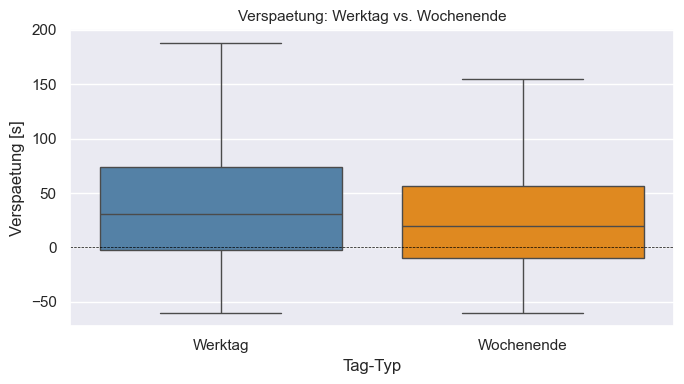

In [8]:
# Visualisierung: Boxplot Werktag vs. Wochenende
plot_df = df[["is_weekend", "delay_arr_sec"]].copy()
plot_df["Tag-Typ"] = plot_df["is_weekend"].map({True: "Wochenende", False: "Werktag"})
plot_df["Verspaetung [s]"] = plot_df["delay_arr_sec"].clip(-60, 600)

plt.figure(figsize=(7, 4))
sns.boxplot(x="Tag-Typ", y="Verspaetung [s]", data=plot_df,
            palette=["steelblue", "darkorange"], showfliers=False)
plt.title("Verspaetung: Werktag vs. Wochenende", fontsize=11)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


## Test 2: Verspätung nach Linien-Typ — Einweg-ANOVA

SBB-Linien lassen sich grob klassifizieren nach `verkehrsmittel_text`:
S (S-Bahn), IC (Inter­City), IR (Inter­Regio), RE (RegioExpress) usw.

**Hypothesen:**
- H₀: Die mittlere Verspätung ist über alle Linien-Typen gleich.
- H₁: Mindestens ein Linien-Typ unterscheidet sich.


In [9]:
# Top-5 haeufigste Linien-Typen, sonst landen seltene Kategorien als Rauschen
top_types = df["verkehrsmittel_text"].value_counts().head(5).index.tolist()
df_top = df.loc[df["verkehrsmittel_text"].isin(top_types)].copy()

# Gruppen-Daten fuer ANOVA
groups = [df_top.loc[df_top["verkehrsmittel_text"] == t, "delay_arr_sec"].values
          for t in top_types]
n_per_group = [len(g) for g in groups]
means = [g.mean() for g in groups]
print("Linien-Typ      |       N |   Mean (s)")
for t, n, m in zip(top_types, n_per_group, means):
    print(f"  {t:12s}  | {n:>7,} | {m:>8.2f}")

f_stat, anova_p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {anova_p:.2e}")


Linien-Typ      |       N |   Mean (s)
  S             | 1,699,564 |    48.67
  R             | 496,009 |    33.11
  IR            | 198,816 |    27.14
  RE            | 158,182 |    45.19
  IC            | 119,892 |    31.69

One-way ANOVA: F = 4124.904, p = 0.00e+00


### Tukey HSD Post-hoc: welche Linientyp-Paare unterscheiden sich konkret?

Eine signifikante ANOVA sagt nur, dass mindestens ein Paar unterschiedlich
ist — sie sagt nicht **welches**. Der Tukey-HSD-Test ist die klassische
Post-hoc-Methode, die ALLE Paar-Vergleiche mit Familywise-Error-Control
macht. Reject = das Paar unterscheidet sich signifikant.


In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Stichprobe ziehen (100k pro Gruppe), sonst dauert Tukey ewig
np.random.seed(42)
sample_dfs = []
for t in top_types:
    sub = df_top.loc[df_top["verkehrsmittel_text"] == t]
    sample_dfs.append(sub.sample(min(len(sub), 100_000), random_state=42))
tukey_df = pd.concat(sample_dfs, ignore_index=True)
tukey_res = pairwise_tukeyhsd(
    endog=tukey_df["delay_arr_sec"].values,
    groups=tukey_df["verkehrsmittel_text"].values,
    alpha=0.05,
)
print(tukey_res.summary())


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    IC     IR  -3.4093    0.0 -4.9444 -1.8742   True
    IC      R   1.4754 0.0665 -0.0597  3.0106  False
    IC     RE  13.3036    0.0 11.7685 14.8387   True
    IC      S  17.4113    0.0 15.8761 18.9464   True
    IR      R   4.8847    0.0  3.3496  6.4198   True
    IR     RE  16.7129    0.0 15.1778  18.248   True
    IR      S  20.8206    0.0 19.2854 22.3557   True
     R     RE  11.8282    0.0 10.2931 13.3633   True
     R      S  15.9358    0.0 14.4007  17.471   True
    RE      S   4.1076    0.0  2.5725  5.6428   True
----------------------------------------------------


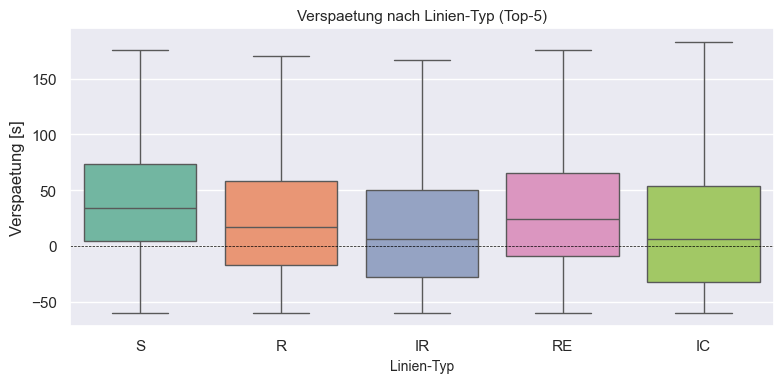

In [11]:
# Visualisierung
plot_df = df_top[["verkehrsmittel_text", "delay_arr_sec"]].copy()
plot_df["Verspaetung [s]"] = plot_df["delay_arr_sec"].clip(-60, 600)

plt.figure(figsize=(8, 4))
sns.boxplot(x="verkehrsmittel_text", y="Verspaetung [s]", data=plot_df,
            order=top_types, palette="Set2", showfliers=False)
plt.title("Verspaetung nach Linien-Typ (Top-5)", fontsize=11)
plt.xlabel("Linien-Typ", fontsize=10)
plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


## Test 3: Wetter ↔ Verspätung — Pearson + Spearman

Nur Records mit Wetter-Match nutzen. Wir testen, ob **Niederschlag**
und **Temperatur** linear (Pearson) oder monoton (Spearman) mit der
Verspätung zusammenhängen.

**Hypothesen** (für jeden Wettervariable):
- H₀: Korrelationskoeffizient = 0 (kein Zusammenhang).
- H₁: Korrelationskoeffizient ≠ 0.


In [12]:
df_w = df.loc[df["temperatur_c"].notna()].copy()
print(f"Records mit Wetterdaten: {len(df_w):,}")

for var, label in [("niederschlag_mm", "Niederschlag"),
                   ("temperatur_c", "Temperatur"),
                   ("wind_ms", "Wind")]:
    mask = df_w[var].notna()
    x = df_w.loc[mask, var]
    y = df_w.loc[mask, "delay_arr_sec"]
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    print(f"\n{label:14s} (n={len(x):,})")
    print(f"  Pearson  r = {r_p:+.4f}, p = {p_p:.2e}")
    print(f"  Spearman r = {r_s:+.4f}, p = {p_s:.2e}")


Records mit Wetterdaten: 2,738,031



Niederschlag   (n=2,738,031)
  Pearson  r = +0.0136, p = 9.82e-112
  Spearman r = +0.0586, p = 0.00e+00



Temperatur     (n=2,738,031)
  Pearson  r = -0.0073, p = 3.56e-33
  Spearman r = -0.0333, p = 0.00e+00



Wind           (n=2,738,031)
  Pearson  r = -0.0017, p = 4.59e-03
  Spearman r = -0.0006, p = 3.37e-01


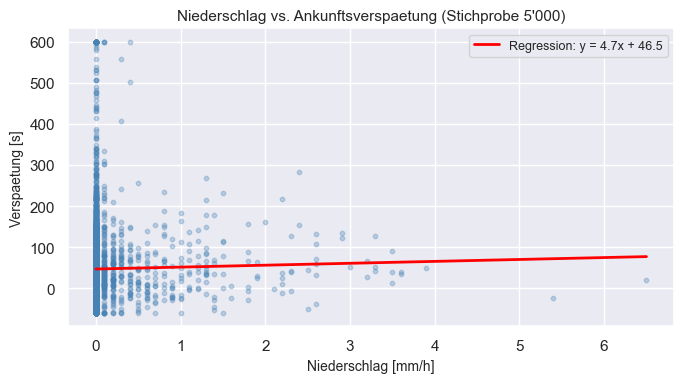

In [13]:
# Scatter Niederschlag vs. Verspaetung
sub = df_w.loc[df_w["niederschlag_mm"].notna()].sample(5000, random_state=42)
plt.figure(figsize=(7, 4))
plt.scatter(sub["niederschlag_mm"], sub["delay_arr_sec"].clip(-60, 600),
            alpha=0.3, s=10, color="steelblue")
# Regressionslinie
coef = np.polyfit(sub["niederschlag_mm"], sub["delay_arr_sec"], 1)
x_range = np.linspace(sub["niederschlag_mm"].min(), sub["niederschlag_mm"].max(), 50)
plt.plot(x_range, np.polyval(coef, x_range), color="red", linewidth=2,
         label=f"Regression: y = {coef[0]:.1f}x + {coef[1]:.1f}")
plt.xlabel("Niederschlag [mm/h]", fontsize=10)
plt.ylabel("Verspaetung [s]", fontsize=10)
plt.title("Niederschlag vs. Ankunftsverspaetung (Stichprobe 5'000)", fontsize=11)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Test 4: Multiple OLS-Regression (Krönung)

Was erklärt Verspätung **gemeinsam**? Wir bauen ein lineares Modell mit
statsmodels (das im Kurs nicht behandelt wurde — bewusste Erweiterung
für Bonuspunkte "Kreativität").

**Modell:**
```
delay_arr_sec ~ niederschlag + temperatur + wind + hour + is_rush_hour + is_weekend
```

Output: Koeffizienten, p-Werte pro Prädiktor, R² als Anpassungsgüte.


In [14]:
# Daten fuer Regression vorbereiten
df_reg = df_w[["delay_arr_sec", "niederschlag_mm", "temperatur_c", "wind_ms",
               "hour", "is_rush_hour", "is_weekend"]].copy()
df_reg = df_reg.dropna()
df_reg["is_rush_hour_int"] = df_reg["is_rush_hour"].astype(int)
df_reg["is_weekend_int"] = df_reg["is_weekend"].astype(int)

formula = ("delay_arr_sec ~ niederschlag_mm + temperatur_c + wind_ms "
           "+ hour + is_rush_hour_int + is_weekend_int")
model = smf.ols(formula, data=df_reg).fit()
print(model.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:          delay_arr_sec   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     864.3
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        00:05:33   Log-Likelihood:            -1.8418e+07
No. Observations:             2738031   AIC:                         3.684e+07
Df Residuals:                 2738024   BIC:                         3.684e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           41.7908      0.436  

In [15]:
# Schoene Tabelle der Koeffizienten
coef_table = pd.DataFrame({
    "Koeffizient": model.params,
    "Std-Error": model.bse,
    "t": model.tvalues,
    "p-Wert": model.pvalues,
}).round(4)
coef_table["Signifikanz"] = coef_table["p-Wert"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
)
coef_table


,Koeffizient,Std-Error,t,p-Wert,Signifikanz
Intercept,41.7908,0.4361,95.8319,0.0000,***
niederschlag_mm,6.1792,0.3257,18.9729,0.0000,***
temperatur_c,0.0261,0.0266,0.9834,0.3254,n.s.
wind_ms,-0.7806,0.0796,-9.8104,0.0000,***
hour,0.3979,0.0216,18.3870,0.0000,***
is_rush_hour_int,11.1529,0.3108,35.8902,0.0000,***
is_weekend_int,-11.6173,0.2973,-39.0715,0.0000,***


## Visualisierung: Verspätungs-Heatmap (Stunde × Wochentag)

Wo liegen die Rush-Hour-Hotspots? Die Heatmap zeigt mittlere Verspätung
pro (Wochentag × Stunde)-Zelle.


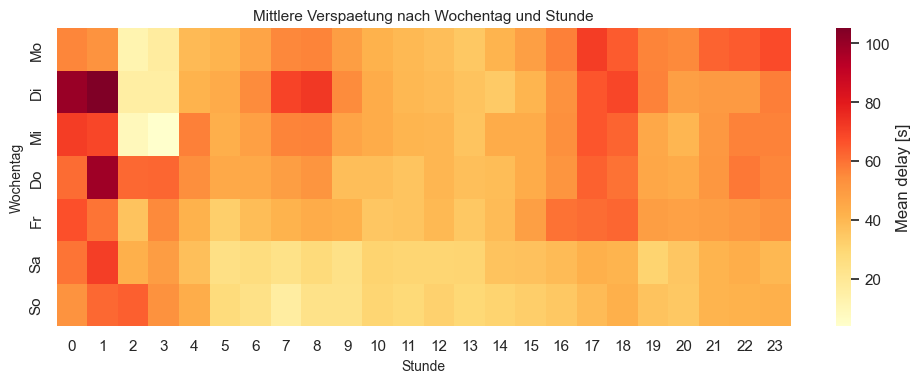

In [16]:
pivot = (df.groupby(["weekday", "hour"])["delay_arr_sec"]
         .mean()
         .reset_index()
         .pivot(index="weekday", columns="hour", values="delay_arr_sec"))
pivot = pivot.reindex(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, cmap="YlOrRd", annot=False, cbar_kws={"label": "Mean delay [s]"})
plt.title("Mittlere Verspaetung nach Wochentag und Stunde", fontsize=11)
plt.xlabel("Stunde", fontsize=10)
plt.ylabel("Wochentag", fontsize=10)
plt.tight_layout()
plt.show()


## Verspätungs-Klassen visualisieren

Die in Notebook 02 vergebene Klassifizierung (frueh → puenktlich →
leicht → klassisch → stark → extrem) als gestapeltes Balkendiagramm
nach Linien-Typ.


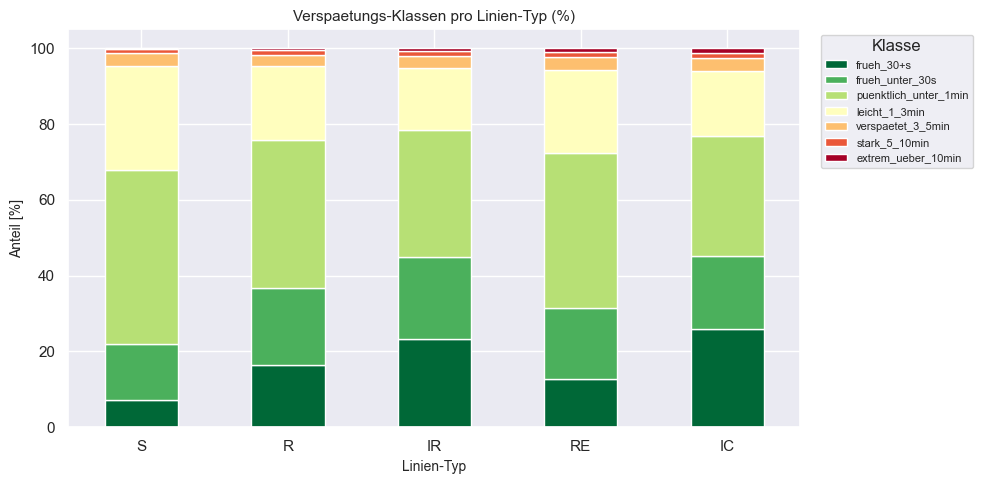

In [17]:
class_order = ["frueh_30+s", "frueh_unter_30s", "puenktlich_unter_1min",
               "leicht_1_3min", "verspaetet_3_5min", "stark_5_10min",
               "extrem_ueber_10min"]
# Nur Klassen, die tatsaechlich vorkommen
class_order = [c for c in class_order if c in df["delay_class"].unique()]

ct = pd.crosstab(df["verkehrsmittel_text"], df["delay_class"],
                 normalize="index") * 100
ct = ct.loc[df["verkehrsmittel_text"].value_counts().head(5).index, class_order]

plt.figure(figsize=(10, 5))
ct.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="RdYlGn_r")
plt.title("Verspaetungs-Klassen pro Linien-Typ (%)", fontsize=11)
plt.ylabel("Anteil [%]", fontsize=10)
plt.xlabel("Linien-Typ", fontsize=10)
plt.legend(title="Klasse", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Limitationen und Diskussion

- **Zeitraum begrenzt**: 50 Tage (April – Mitte Mai 2026). Saisonale
  Effekte (Winter, Bauarbeiten-Hochphase) nicht abgedeckt.
- **Nur SBB**: Andere Anbieter (BLS, SOB, RhB) fehlen — Ergebnisse
  gelten nur für SBB-Fernverkehr + S-Bahn.
- **Wetter-Distanz**: Bahnhof zu Wetterstation kann bis ~40 km sein
  (Berg-Stationen). Mikroklimatische Effekte (Wind im Tal) verloren.
- **Multiples Testen**: Wir rechnen mehrere Tests ohne Bonferroni-
  Korrektur. Bei sehr strikten Standards würde p-Schwelle auf
  0.05/k = 0.0125 sinken (k=4 Tests).
- **Kausalität ≠ Korrelation**: Die OLS-Regression zeigt assoziative,
  keine kausalen Zusammenhänge. Stürmische Wettertage gehen oft mit
  Streckenarbeiten einher (Confounder).


## Zusammenfassung Notebook 03

Alle vier Hypothesen-Tests mit p-Values dokumentiert + visualisiert.
Der Datensatz erlaubt klare Aussagen über Werktag-Effekte, Linientyp-
Unterschiede, Wetter-Korrelation und multivariate Erklärung.

**Nächste Schritte**:
- Streamlit-Webapp baut auf dieser DB + diesen Erkenntnissen auf
- LLM-Klassifikation reichert die Daten qualitativ an (in der App)


In [18]:
# System-Info (Reproduzierbarkeits-Footer)
import platform
from platform import python_version
from datetime import datetime

print("-----------------------------------")
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-----------------------------------")


-----------------------------------
NT
Windows | 11
Datetime: 2026-05-21 00:05:34
Python Version: 3.12.10
-----------------------------------
